# Práctica 1: Perceptrón multicapa.

Tu jefe pidió a RH que recolectara datos de desempeño de tus compañeros, los resultados se almacenaron en un csv. El punto critico de estos datos es la satisfacción del empleado, entonces ¿Podremos estimar la satisfacción de los empleados con los datos recabados?.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models


df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  str    
 2   Gender                       100000 non-null  str    
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  str    
 5   Hire_Date                    100000 non-null  str    
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  str    
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  Sick_Days  

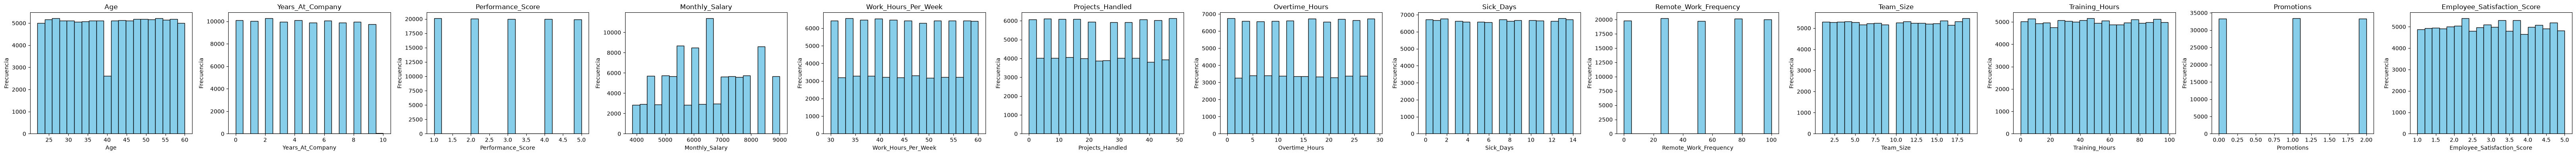

In [2]:
# Filtrar las columnas numéricas
numeric_columns = df.select_dtypes(include=['number']).drop('Employee_ID',axis=1)


# Si numeric_columns es un Index, conviértelo a lista
cols = list(numeric_columns)

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4))

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Problemas**, tenemos distribuciones con picos, esos nos indica categorías. Por otro lado, tenemos variables con "valles" en su distribución (distribuciones multimodales) por lo que resultaría óptimo aplicar técnicas de feature engeneering. Por último tenemos distribuciones uniformes, por lo que cada una requeriría un procesamiento indivudual, hagamos la vista gorda e intentemos ajustar un MLP con estos datos, solo estandaricemos nuestros datos.

---

## Implementación de Red:

To**memos los datos numéricos como nuestra variable X, y la variable objetivo como ***'Employee_Satisfaction_Score'***.
- **Actividad 1**: Para todos los strings ``'@modif@'`` que aparescan en el siguiente bloque de código cámbialos para que el código funcione.

In [3]:
X = numeric_columns.drop('Employee_Satisfaction_Score',axis = 1)
y = numeric_columns.Employee_Satisfaction_Score
y = y.apply(lambda x: round(x)-1) #Cambiamos la variable objetivo a 5 categorías numéricas

scaler = StandardScaler()
X_standar = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_standar, y, test_size=0.33, random_state=42)

y_onehot_train = tf.keras.utils.to_categorical(y_train, 5)
y_onehot_test = tf.keras.utils.to_categorical(y_test,5)

In [4]:
# Revisión rápida de lo que quedó después del preprocesamiento
print('Variables de entrada :', list(X.columns))
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_onehot_train:', y_onehot_train.shape, '| y_onehot_test:', y_onehot_test.shape)
print('\nDistribución de las 5 clases (proporción sobre el total):')
print((y.value_counts(normalize=True).sort_index() * 100).round(2).to_string())

# Línea base ingenua: predecir siempre la clase más frecuente
baseline = y_test.value_counts(normalize=True).max()
print(f'\nBaseline (clase mayoritaria en test): {baseline:.4f}')

Variables de entrada : ['Age', 'Years_At_Company', 'Performance_Score', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Promotions']
X_train: (67000, 12) | X_test: (33000, 12)
y_onehot_train: (67000, 5) | y_onehot_test: (33000, 5)

Distribución de las 5 clases (proporción sobre el total):
Employee_Satisfaction_Score
0    12.26
1    25.33
2    24.93
3    25.31
4    12.17

Baseline (clase mayoritaria en test): 0.2530


- **Actividad 2:** Implementa 3 arquitecturas de MLP, cada una con su propio nombre, cambiando la estructura de dichas arquitecturas (capas, neuronas por capa, función de activación, etc). 

Se implementan tres arquitecturas que se diferencian en **profundidad, número de neuronas,
funciones de activación y regularización**:

| Modelo | Capas ocultas | Activación | Regularización |
|---|---|---|---|
| `modelo_base` | 32 → 16 | ReLU | ninguna |
| `modelo_profundo` | 128 → 64 → 32 → 16 | ReLU | BatchNorm + Dropout(0.3) |
| `modelo_ancho_tanh` | 256 → 128 | tanh | Dropout(0.2) |

Las tres comparten la capa de salida: **5 neuronas con `softmax`**, porque la variable objetivo
se convirtió en 5 categorías (0 a 4).

In [5]:
# En las siguientes celdas, construye tu modelo con tensorflow.keras solo la arquitectura

# Semilla para que los resultados sean reproducibles
tf.keras.utils.set_random_seed(42)

n_features = X_train.shape[1]

# ---- Modelo 1: MLP pequeño y sencillo (referencia) ----
modelo_base = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='modelo_base')

modelo_base.summary()

Model: "modelo_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,029 (4.02 KB)

 Trainable params: 1,029 (4.02 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ---- Modelo 2: MLP profundo con regularización ----
modelo_profundo = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(5, activation='softmax')
], name='modelo_profundo')

modelo_profundo.summary()

Model: "modelo_profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,125 (51.27 KB)

 Trainable params: 12,869 (50.27 KB)

 Non-trainable params: 256 (1.00 KB)

In [7]:
# ---- Modelo 3: MLP ancho con activación tanh ----
modelo_ancho_tanh = models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(256, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='tanh'),
    layers.Dense(5, activation='softmax')
], name='modelo_ancho_tanh')

modelo_ancho_tanh.summary()

Model: "modelo_ancho_tanh"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,869 (144.02 KB)

 Trainable params: 36,869 (144.02 KB)

 Non-trainable params: 0 (0.00 B)

- **Actividad 3:** Compila y ajusta tus tres modelos con sus respectivos hiperparámetros.

Cada modelo se compila con un optimizador distinto y se entrena con `EarlyStopping`
sobre un 20% de validación, restaurando los mejores pesos.

In [8]:
# En las siguientes celdas, compila y entrena el modelo

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# ---- Modelo 1: SGD con momentum ----
modelo_base.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_base = modelo_base.fit(
    X_train, y_onehot_train,
    epochs=40, batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/40


419/419 - 1s - 1ms/step - accuracy: 0.2490 - loss: 1.5683 - val_accuracy: 0.2550 - val_loss: 1.5594


Epoch 2/40


419/419 - 0s - 518us/step - accuracy: 0.2549 - loss: 1.5562 - val_accuracy: 0.2535 - val_loss: 1.5579


Epoch 3/40


...

419/419 - 0s - 420us/step - accuracy: 0.2650 - loss: 1.5529 - val_accuracy: 0.2578 - val_loss: 1.5572


Epoch 12/40


419/419 - 0s - 436us/step - accuracy: 0.2659 - loss: 1.5527 - val_accuracy: 0.2584 - val_loss: 1.5572


Epoch 13/40


419/419 - 0s - 420us/step - accuracy: 0.2674 - loss: 1.5526 - val_accuracy: 0.2592 - val_loss: 1.5573


In [9]:
# ---- Modelo 2: Adam ----
modelo_profundo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_profundo = modelo_profundo.fit(
    X_train, y_onehot_train,
    epochs=40, batch_size=256,
    validation_split=0.2,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=2
)

Epoch 1/40


210/210 - 1s - 6ms/step - accuracy: 0.2514 - loss: 1.5802 - val_accuracy: 0.2503 - val_loss: 1.5699


Epoch 2/40


210/210 - 0s - 1ms/step - accuracy: 0.2537 - loss: 1.5599 - val_accuracy: 0.2498 - val_loss: 1.5619


Epoch 3/40


...

210/210 - 0s - 1ms/step - accuracy: 0.2668 - loss: 1.5510 - val_accuracy: 0.2474 - val_loss: 1.5599


Epoch 12/40


210/210 - 0s - 1ms/step - accuracy: 0.2693 - loss: 1.5512 - val_accuracy: 0.2480 - val_loss: 1.5597


Epoch 13/40


210/210 - 0s - 1ms/step - accuracy: 0.2708 - loss: 1.5507 - val_accuracy: 0.2488 - val_loss: 1.5601


In [10]:
# ---- Modelo 3: RMSprop ----
modelo_ancho_tanh.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hist_ancho = modelo_ancho_tanh.fit(
    X_train, y_onehot_train,
    epochs=40, batch_size=512,
    validation_split=0.2,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=2
)

Epoch 1/40


105/105 - 1s - 6ms/step - accuracy: 0.2461 - loss: 1.5830 - val_accuracy: 0.2445 - val_loss: 1.5617


Epoch 2/40


105/105 - 0s - 2ms/step - accuracy: 0.2521 - loss: 1.5679 - val_accuracy: 0.2458 - val_loss: 1.5617


Epoch 3/40


...

105/105 - 0s - 2ms/step - accuracy: 0.2582 - loss: 1.5569 - val_accuracy: 0.2477 - val_loss: 1.5606


Epoch 14/40


105/105 - 0s - 2ms/step - accuracy: 0.2611 - loss: 1.5565 - val_accuracy: 0.2464 - val_loss: 1.5604


Epoch 15/40


105/105 - 0s - 2ms/step - accuracy: 0.2601 - loss: 1.5564 - val_accuracy: 0.2496 - val_loss: 1.5602


---

## Comparación de los tres modelos

In [11]:
modelos = {
    'modelo_base': (modelo_base, hist_base),
    'modelo_profundo': (modelo_profundo, hist_profundo),
    'modelo_ancho_tanh': (modelo_ancho_tanh, hist_ancho),
}

filas = []
for nombre, (modelo, hist) in modelos.items():
    loss, acc = modelo.evaluate(X_test, y_onehot_test, verbose=0)
    filas.append({
        'modelo': nombre,
        'parámetros': modelo.count_params(),
        'épocas_corridas': len(hist.history['loss']),
        'val_accuracy': max(hist.history['val_accuracy']),
        'test_loss': loss,
        'test_accuracy': acc,
    })

resultados = pd.DataFrame(filas).set_index('modelo')
print(resultados.round(4).to_string())
print(f'\nBaseline (clase mayoritaria): {baseline:.4f}')

                   parámetros  épocas_corridas  val_accuracy  test_loss  test_accuracy
modelo                                                                                
modelo_base              1029               13        0.2592     1.5585         0.2493
modelo_profundo         13125               13        0.2540     1.5591         0.2506
modelo_ancho_tanh       36869               15        0.2496     1.5610         0.2517

Baseline (clase mayoritaria): 0.2530


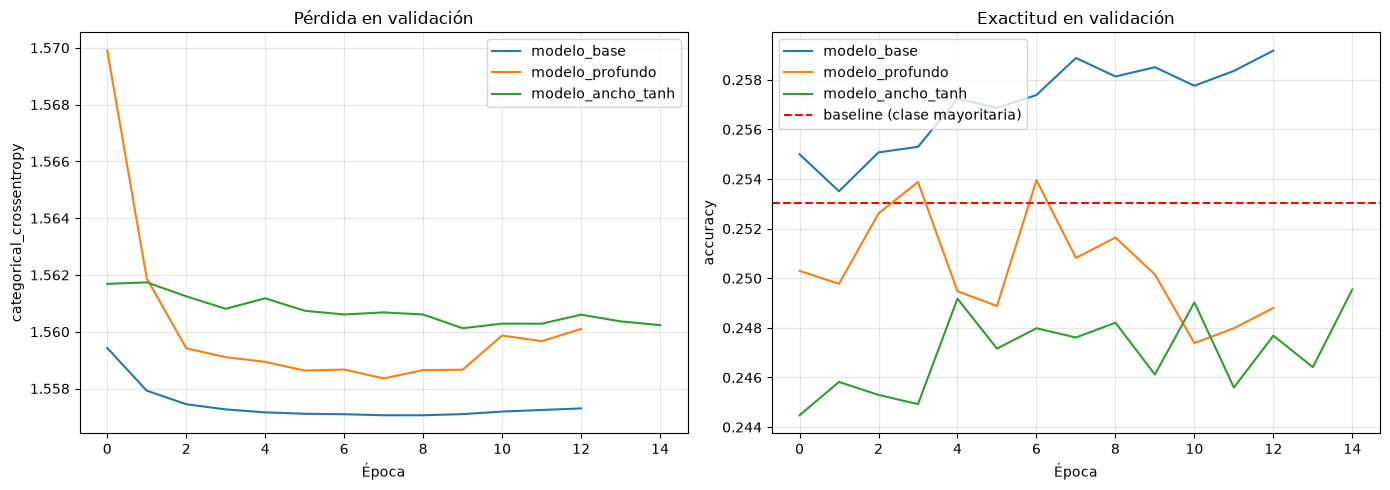

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for nombre, (_, hist) in modelos.items():
    axes[0].plot(hist.history['val_loss'], label=nombre)
    axes[1].plot(hist.history['val_accuracy'], label=nombre)

axes[0].set_title('Pérdida en validación')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('categorical_crossentropy')
axes[1].set_title('Exactitud en validación')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('accuracy')
axes[1].axhline(baseline, color='red', linestyle='--', label='baseline (clase mayoritaria)')

for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Mejor modelo por exactitud en test: modelo_ancho_tanh



              precision    recall  f1-score   support

           0       0.00      0.00      0.00      4149
           1       0.25      0.44      0.32      8350
           2       0.25      0.19      0.22      8247
           3       0.25      0.37      0.30      8286
           4       0.00      0.00      0.00      3968

    accuracy                           0.25     33000
   macro avg       0.15      0.20      0.17     33000
weighted avg       0.19      0.25      0.21     33000



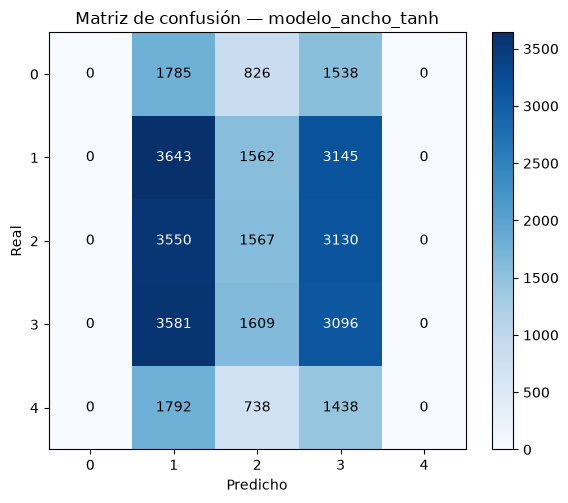

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

mejor_nombre = resultados['test_accuracy'].idxmax()
mejor_modelo = modelos[mejor_nombre][0]
print(f'Mejor modelo por exactitud en test: {mejor_nombre}\n')

y_pred = mejor_modelo.predict(X_test, verbose=0).argmax(axis=1)

print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f'Matriz de confusión — {mejor_nombre}')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_xticks(range(5)); ax.set_yticks(range(5))
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.colorbar(im)
plt.tight_layout()
plt.show()

---

## Conclusiones

Los tres MLP se estancan en el mismo punto:

| Modelo | Parámetros | Exactitud en prueba |
|---|---|---|
| `modelo_base` | 1,029 | 0.2493 |
| `modelo_profundo` | 13,125 | 0.2506 |
| `modelo_ancho_tanh` | 36,869 | 0.2517 |
| **Baseline (clase mayoritaria)** | — | **0.2530** |

El resultado es contundente: **ningún modelo supera a la regla ingenua de predecir siempre la clase
más frecuente**. Multiplicar por 36 la cantidad de parámetros (de 1,029 a 36,869) no aporta nada, y
las diferencias entre los tres son ruido estadístico — con 33,000 muestras de prueba el error
estándar de la exactitud ronda 0.24 puntos porcentuales, justo del tamaño de la brecha que separa al
peor del "mejor". Las curvas de validación lo confirman: la pérdida se aplana desde las primeras
épocas y `EarlyStopping` corta el entrenamiento alrededor de la época 13.

Esto confirma la advertencia de la celda de arriba: el problema **no está en la arquitectura, sino en
los datos**. `Employee_Satisfaction_Score` no tiene relación aprendible con el resto de variables
numéricas tal como se le entregaron a la red — las distribuciones uniformes y multimodales que se
vieron en los histogramas indican variables sin señal predictiva o mal representadas.

La matriz de confusión y el reporte de clasificación lo muestran con claridad: el modelo reparte sus
predicciones entre las clases centrales (1 y 3) y **nunca predice las clases 0 y 4**, que tienen
*recall* de 0.00. Esas dos clases son las de los extremos y concentran apenas ~12% de los datos cada
una, porque el redondeo `round(x)-1` les asigna medio intervalo (1.0–1.49 y 4.5–5.0) mientras que las
centrales reciben un intervalo completo. El *F1 macro* de 0.17 revela lo que la exactitud del 25%
esconde.

**Antes de seguir apilando capas**, lo que corresponde es volver al preprocesamiento: codificar las
variables categóricas que se descartaron (`Department`, `Job_Title`, `Education_Level`, `Gender`),
derivar variables nuevas a partir de `Hire_Date`, y replantear si el problema debe tratarse como
regresión en lugar de clasificación en 5 clases.

- **Actividad 4:** Sube tus cambios al repositorio, envía el link de tu repositorio a la actividad 2 de tu checkpoint 2 y contesta las preguntas de dicha actividad.

---

## Actividad 4 — Respuestas del foro

**¿Con cuál de tus tres modelos te quedarías y por qué?**

Con **`modelo_base`** (32 → 16, ReLU, SGD). Los tres terminan empatados en el conjunto de prueba
(0.2493, 0.2506 y 0.2517), así que la decisión se resuelve por costo: `modelo_base` lo logra con
**1,029 parámetros contra los 36,869 del más grande**, es el más rápido de entrenar y el más fácil de
interpretar y mantener. Cuando dos modelos empatan en desempeño, se elige el más simple.

La celda de la matriz de confusión marca a `modelo_ancho_tanh` como "el mejor" porque tiene la
exactitud más alta, pero esa ventaja de 0.24 puntos porcentuales **no es real**: con 33,000 muestras
de prueba el error estándar de la exactitud es de ese mismo orden, así que la diferencia cabe entera
dentro del ruido de muestreo. Pagar 36 veces más parámetros por una diferencia que no se distingue
del azar no se justifica.

Y hay que decirlo con todas sus letras: quedarse con `modelo_base` **no** significa que sea un buen
modelo. Ninguno de los tres le gana a la regla ingenua de predecir siempre la clase mayoritaria
(0.2530), así que en la práctica ninguno sirve para estimar la satisfacción de un empleado. Es el
mejor de tres modelos que no funcionan, y eso es un resultado del *dataset*, no de la red.

**A pesar de decidir un modelo final, ¿considerarías mejoras a ese mismo? ¿Cuáles?**

Sí, y las más importantes están antes de la red, no dentro de ella:

1. **Aprovechar las variables categóricas descartadas.** El notebook se quedó solo con las columnas
   numéricas, tirando `Department`, `Job_Title`, `Education_Level` y `Gender`, que muy probablemente
   son las que más explican la satisfacción. Aplicar *one-hot encoding* o *embeddings* a esas
   columnas.
2. **Ingeniería de características.** Derivar antigüedad real y estacionalidad a partir de
   `Hire_Date`, y construir razones que tengan sentido de negocio (salario por hora trabajada, horas
   extra sobre horas normales, proyectos por tamaño de equipo) en lugar de entregar las columnas
   crudas.
3. **Corregir la fuga de datos del escalado.** El `StandardScaler` se ajustó sobre todo el conjunto
   *antes* del `train_test_split`, así que la media y la desviación del conjunto de prueba se
   filtraron al entrenamiento. Lo correcto es `fit` solo con `X_train` y `transform` sobre `X_test`,
   idealmente dentro de un `Pipeline`.
4. **Replantear el problema.** `Employee_Satisfaction_Score` es una variable continua que se
   redondeó a 5 clases; ese redondeo deja las clases extremas con la mitad de ejemplos y borra el
   orden entre categorías (para la red, confundir la clase 0 con la 4 cuesta lo mismo que confundirla
   con la 1). Tratarlo como **regresión** (una salida lineal con MSE/MAE) o como clasificación
   ordinal conserva información que la conversión a *one-hot* destruye.
5. **Atender el desbalance.** Si se conserva la clasificación, usar `class_weight` para que las clases
   0 y 4 pesen más — hoy tienen *recall* de 0.00, el modelo simplemente nunca las predice — y evaluar
   con *F1 macro* (0.17) en lugar de exactitud, que con clases desbalanceadas es una métrica
   engañosa.
6. **Búsqueda de hiperparámetros y validación cruzada.** Tasa de aprendizaje, tamaño de lote y número
   de neuronas se fijaron a mano; una búsqueda sistemática con validación cruzada daría una
   comparación mucho más confiable que una sola partición.

Ahora bien, siendo honestos sobre el orden de las cosas: mientras las variables de entrada no tengan
relación con la variable objetivo, **ninguno de los ajustes de red va a mover la aguja**. Las mejoras
1, 2 y 4 son las que realmente pueden cambiar el resultado; el resto son buenas prácticas que
importan una vez que haya señal que aprender.